# Bài tập buổi 6 — Hồi quy tuyến tính

**Sinh viên thực hiện:** Tạ Tuấn Khải

---

## Bối cảnh

Trong bài tập này, bạn sẽ làm việc với bộ dữ liệu **California Housing** (Dự đoán giá nhà tại California dựa trên các đặc trưng nhân khẩu học và địa lý). Bài toán đặt ra là bài toán **Hồi quy (Regression)**.

Nhiệm vụ của bạn là xây dựng luồng xử lý dữ liệu và huấn luyện 3 biến thể của Hồi quy tuyến tính:
1. **Vanilla Linear Regression** (Hồi quy tuyến tính thông thường)
2. **Ridge Regression** (Hồi quy với chuẩn hóa L2)
3. **Lasso Regression** (Hồi quy với chuẩn hóa L1)

## Mục tiêu bài tập

1. Thực hiện Load dữ liệu và Khám phá dữ liệu (EDA) cơ bản.
2. Chia tập Train/Test và tiền xử lý (Scaling) đúng chuẩn, không gây Data Leakage.
3. Huấn luyện và đánh giá mô hình bằng các metric chuẩn cho Regression (RMSE, R²).
4. **Trực quan hóa hệ số hồi quy (Coefficients)** để hiểu rõ tính chất thu nhỏ (shrinkage) của Ridge và khả năng chọn lọc đặc trưng (feature selection) của Lasso.

---


## 0. Chuẩn bị môi trường & Import Thư viện

Ô này chứa sẵn các thư viện cần thiết. Nếu bạn cần dùng thêm thư viện nào, hãy bổ sung vào đây.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)  # Cố định random seed
print("Đã import xong thư viện.")

Đã import xong thư viện.


---
## Task 1 — Tải dữ liệu và Khám phá ban đầu (EDA)

### Yêu cầu
1. Tải bộ dữ liệu `California Housing` từ `sklearn.datasets`.
2. Chuyển đổi thành pandas DataFrame. Gán cột target là `MedHouseVal` (Giá nhà trung bình - đơn vị trăm nghìn USD).
3. In ra số dòng, số cột (shape) và thông tin kiểu dữ liệu (`.info()`).
4. Kiểm tra xem có giá trị thiếu (Missing values) nào trong bộ dữ liệu không.

### Gợi ý
- Hàm `fetch_california_housing(as_frame=True)` hỗ trợ trả về DataFrame trực tiếp qua thuộc tính `.frame`.
- Dùng `df.isnull().sum()` để đếm số lượng giá trị thiếu cho mỗi cột.

In [2]:
# TODO 1: Load dữ liệu, tạo DataFrame và kiểm tra tổng quan
local_path = Path("california_housing.csv")

if local_path.exists():
    df = pd.read_csv(local_path)
    if "MedHouseValue" in df.columns and "MedHouseVal" not in df.columns:
        df = df.rename(columns={"MedHouseValue": "MedHouseVal"})
    print(f"Đã tải dữ liệu local: {local_path}")
else:
    california = fetch_california_housing(as_frame=True)
    df = california.frame.copy()
    print("Đã tải bằng fetch_california_housing.")

feature_names = [col for col in df.columns if col != "MedHouseVal"]

print("Shape:", df.shape)
print("\nThông tin dữ liệu:")
df.info()

print("\nSố giá trị thiếu theo cột:")
print(df.isnull().sum())

print("\nNăm dòng đầu:")
display(df.head())


Đã tải bằng fetch_california_housing.
Shape: (20640, 9)

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Số giá trị thiếu theo cột:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Năm dòng đầu:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## Task 2 — Trực quan hóa Phân phối & Tương quan

### Yêu cầu
1. Vẽ biểu đồ Histogram (có đường cong KDE) cho biến mục tiêu `MedHouseVal`. Nhận xét xem phân phối có bị lệch (skew) không.
2. Vẽ ma trận tương quan (Heatmap) giữa tất cả các biến số trong dữ liệu.
3. **Trả lời:** Đặc trưng nào có độ tương quan dương mạnh nhất với giá nhà (`MedHouseVal`)?

### Gợi ý
- Sử dụng `sns.histplot(data=df, x='MedHouseVal', kde=True)` để vẽ phân phối.
- Dùng `df.corr()` để tính ma trận tương quan và đưa vào `sns.heatmap(..., annot=True, cmap='coolwarm', fmt=".2f")` để vẽ biểu đồ nhiệt.

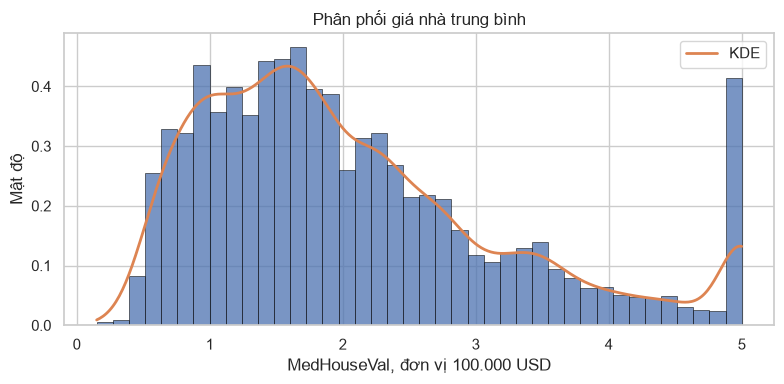

Skewness của MedHouseVal: 0.978


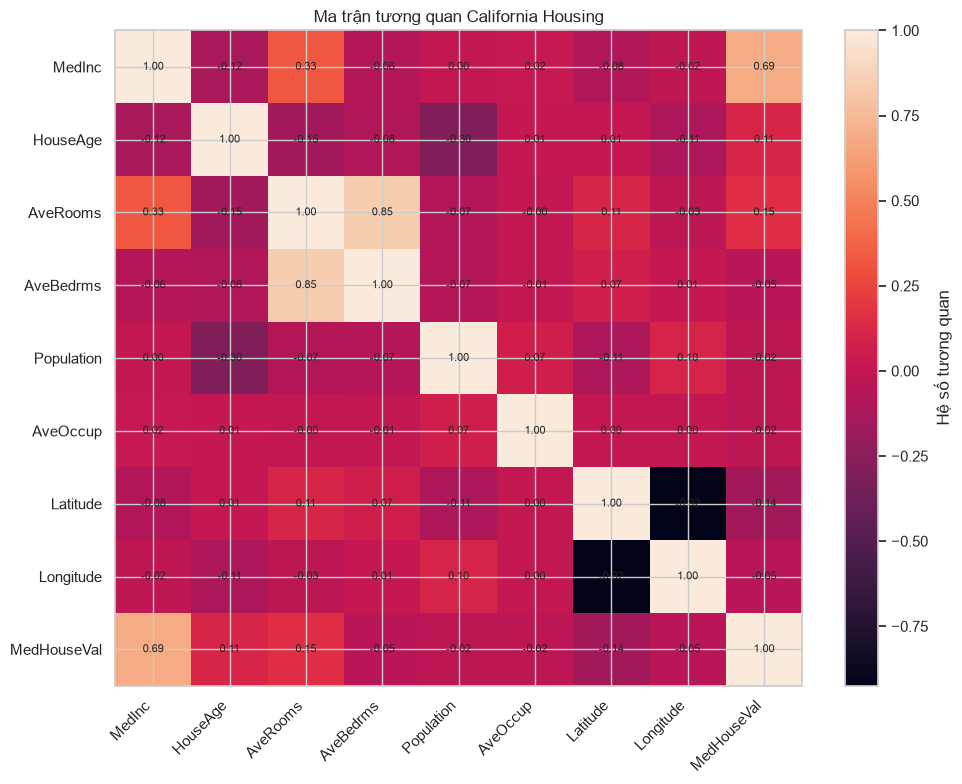

Tương quan với MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [3]:
# TODO 2a: Vẽ Histogram cho biến MedHouseVal
values = df["MedHouseVal"].dropna().to_numpy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(values, bins=40, density=True, edgecolor="black", linewidth=0.5, alpha=0.75)

x_grid = np.linspace(values.min(), values.max(), 400)
kde = gaussian_kde(values)
ax.plot(x_grid, kde(x_grid), linewidth=2, label="KDE")
ax.set_title("Phân phối giá nhà trung bình")
ax.set_xlabel("MedHouseVal, đơn vị 100.000 USD")
ax.set_ylabel("Mật độ")
ax.legend()
plt.tight_layout()
plt.show()

print("Skewness của MedHouseVal:", round(df["MedHouseVal"].skew(), 3))


# TODO 2b: Vẽ Heatmap correlation cho toàn bộ dữ liệu
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr.to_numpy(), aspect="auto")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax, label="Hệ số tương quan")
ax.set_title("Ma trận tương quan California Housing")
plt.tight_layout()
plt.show()

print("Tương quan với MedHouseVal:")
print(corr["MedHouseVal"].sort_values(ascending=False))

**Trả lời 2:**

- `MedHouseVal` lệch phải, skewness khoảng 0.98. Phân phối tập trung nhiều ở vùng giá thấp và trung bình. Có một cụm lớn tại mức khoảng 5.0 do target bị chặn ở ngưỡng trên của bộ dữ liệu.
- `MedInc` có tương quan dương mạnh nhất với `MedHouseVal`, r khoảng 0.69. Tiếp theo là `AveRooms`, r khoảng 0.15, và `HouseAge`, r khoảng 0.11.
- Tương quan không chứng minh quan hệ nhân quả. Heatmap chỉ mô tả quan hệ tuyến tính từng cặp biến.

---
## Task 3 — Chia tập dữ liệu và Tiền xử lý (Scaling)

Với các mô hình có sử dụng Regularization như Ridge và Lasso, việc **Scale dữ liệu** (đưa về cùng thang đo) là **BẮT BUỘC**. Nếu không scale, các đặc trưng có miền giá trị lớn (ví dụ như Population) sẽ lấn át các đặc trưng có miền giá trị nhỏ, làm sai lệch tác dụng của hệ số phạt L1/L2.

### Yêu cầu
1. Tách features (`X`) và target (`y`).
2. Chia tập Train/Test theo tỷ lệ **80/20**.
3. Dùng `StandardScaler` để scale tập `X`. **Quan trọng:** Chỉ `.fit()` trên `X_train`, sau đó dùng tham số đã học đó để `.transform()` cho cả `X_train` và `X_test`.

### Gợi ý
- `train_test_split(X, y, test_size=0.2, random_state=42)`.
- `scaler.fit_transform(X_train)` cho tập train và `scaler.transform(X_test)` cho tập test.

In [4]:
# TODO 3: Chia tập và Scale dữ liệu
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("\nTrung bình các feature train sau scaling, xấp xỉ 0:")
print(np.round(X_train_scaled.mean(axis=0), 4))
print("Độ lệch chuẩn các feature train sau scaling, xấp xỉ 1:")
print(np.round(X_train_scaled.std(axis=0), 4))


Train: (16512, 8) (16512,)
Test: (4128, 8) (4128,)

Trung bình các feature train sau scaling, xấp xỉ 0:
[-0. -0.  0. -0.  0.  0.  0.  0.]
Độ lệch chuẩn các feature train sau scaling, xấp xỉ 1:
[1. 1. 1. 1. 1. 1. 1. 1.]


---
## Task 4 — Huấn luyện Vanilla Linear Regression

### Yêu cầu
1. Khởi tạo và huấn luyện mô hình `LinearRegression` trên tập Train đã scale.
2. Dự đoán trên tập Test.
3. Tính và in ra 2 chỉ số đánh giá: **RMSE** (Root Mean Squared Error) và **R² Score**.

### Gợi ý
- RMSE có thể tính bằng `np.sqrt(mean_squared_error(y_true, y_pred))`.
- Hàm `r2_score(y_true, y_pred)` sẽ trả về chỉ số R² (hệ số xác định).

In [5]:
# TODO 4: Huấn luyện và Đánh giá Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")


Linear Regression - RMSE: 0.7456, R2: 0.5758


---
## Task 5 — Huấn luyện Ridge và Lasso Regression

### Yêu cầu
1. Huấn luyện mô hình **Ridge** với tham số siêu việt `alpha=10.0`.
2. Huấn luyện mô hình **Lasso** với tham số siêu việt `alpha=0.1`.
3. Tính RMSE và R² cho cả 2 mô hình trên tập Test và in kết quả để so sánh.

### Gợi ý
- Khởi tạo mô hình: `Ridge(alpha=10.0)` và `Lasso(alpha=0.1)`.
- Bạn có thể viết một hàm `evaluate_model(model, X_test, y_test)` nhỏ để tái sử dụng code tính RMSE và R² cho đỡ lặp lại.

In [6]:
def evaluate_model(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
    r2 = r2_score(y_eval, y_pred)
    return rmse, r2

# TODO 5a: Huấn luyện và Đánh giá Ridge Regression
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train_scaled, y_train)
rmse_ridge, r2_ridge = evaluate_model(ridge_model, X_test_scaled, y_test)

# TODO 5b: Huấn luyện và Đánh giá Lasso Regression
lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
rmse_lasso, r2_lasso = evaluate_model(lasso_model, X_test_scaled, y_test)

results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge, alpha=10", "Lasso, alpha=0.1"],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso],
    "R2": [r2_lr, r2_ridge, r2_lasso]
}).set_index("Model")

display(results_df.round(4))


,RMSE,R2
Model,,
Linear Regression,0.7456,0.5758
"Ridge, alpha=10",0.7453,0.5761
"Lasso, alpha=0.1",0.8244,0.4814


---
## Task 6 — Trực quan hóa Hệ số hồi quy (Coefficients)

Đây là phần cốt lõi để thấy sự khác biệt về mặt toán học giữa L1 và L2 Regularization.

### Yêu cầu
1. Lấy mảng hệ số hồi quy (`.coef_`) từ cả 3 mô hình (Linear, Ridge, Lasso).
2. Tạo một DataFrame lưu trữ các hệ số này với Index là tên các features.
3. Vẽ biểu đồ Barplot so sánh các trọng số của 3 mô hình cạnh nhau cho từng feature.
4. **Trả lời:** Quan sát hệ số của Lasso, bạn thấy điều gì đặc biệt xảy ra với một số features? Tính chất này thường được ứng dụng để làm gì?

### Gợi ý
- `california.feature_names` trả về danh sách tên cột.
- Có thể gom thành Pandas DataFrame và gọi lệnh `df_coefs.plot(kind='bar', figsize=(12, 6))` để pandas tự động vẽ các thanh cạnh nhau.

,Linear,Ridge,Lasso
MedInc,0.8544,0.8538,0.7106
HouseAge,0.1225,0.1233,0.1065
AveRooms,-0.2944,-0.2924,-0.0000
AveBedrms,0.3393,0.3367,0.0000
Population,-0.0023,-0.0021,-0.0000
AveOccup,-0.0408,-0.0409,-0.0000
Latitude,-0.8969,-0.8894,-0.0115
Longitude,-0.8698,-0.8622,-0.0000


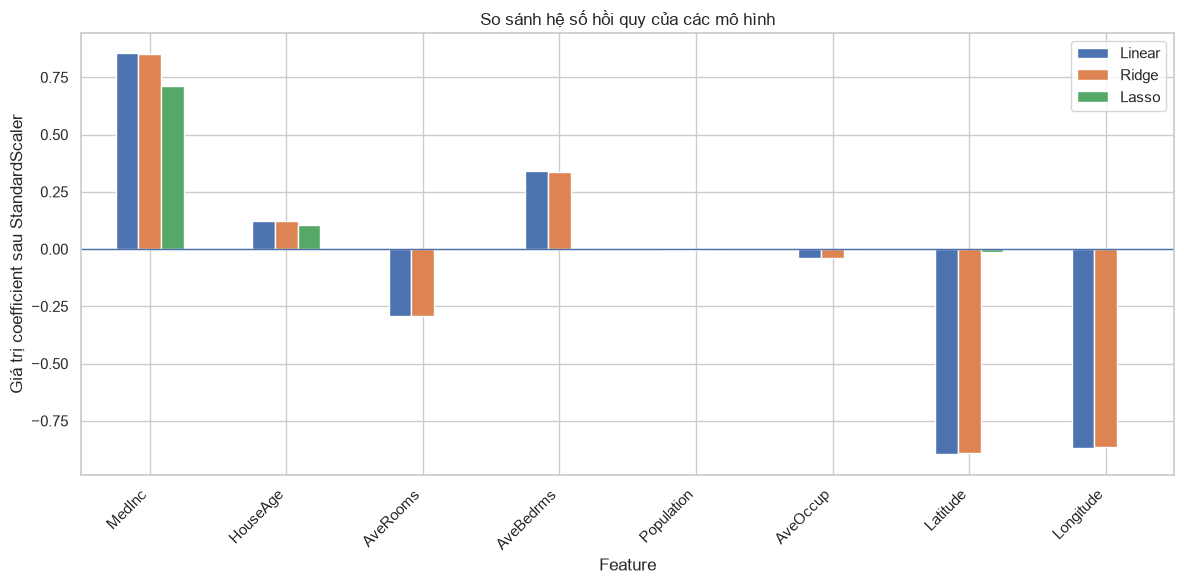

Số hệ số bằng 0 của Lasso: 5
Các feature bị Lasso ép về 0: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']


In [7]:
# TODO 6: Trực quan hóa Coefficients
features = list(X.columns)
coef_df = pd.DataFrame({
    "Linear": lr_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
}, index=features)

display(coef_df.round(4))

ax = coef_df.plot(kind="bar", figsize=(12, 6))
ax.axhline(0, linewidth=1)
plt.title("So sánh hệ số hồi quy của các mô hình")
plt.xlabel("Feature")
plt.ylabel("Giá trị coefficient sau StandardScaler")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Số hệ số bằng 0 của Lasso:", int(np.isclose(lasso_model.coef_, 0).sum()))
print("Các feature bị Lasso ép về 0:",
      [f for f, c in zip(features, lasso_model.coef_) if np.isclose(c, 0)])


**Trả lời 6:**

Với `alpha=0.1`, Lasso ép một số hệ số về đúng 0. Trên lần chạy này, các feature như `AveRooms`, `AveBedrms`, `Population`, `AveOccup` và `Longitude` bị loại khỏi phương trình; hệ số `Latitude` cũng bị thu nhỏ gần 0. Đây là tính chất tạo nghiệm thưa của chuẩn phạt L1.

Tính chất này thường được dùng cho feature selection. Mô hình giữ lại một tập đặc trưng nhỏ hơn, giúp giảm độ phức tạp và tăng khả năng diễn giải. Đổi lại, alpha quá lớn gây underfitting, thể hiện qua RMSE tăng và R² giảm so với Linear Regression và Ridge.

---
## (Bonus) Task 7 — Tìm siêu tham số tối ưu với GridSearchCV

Ở Task 5, chúng ta chỉ chọn bừa `alpha=10.0` và `alpha=0.1`. Làm sao để biết `alpha` bao nhiêu là tốt nhất cho bộ dữ liệu này?

### Yêu cầu
Sử dụng `GridSearchCV` để chạy thử nghiệm nghiệm chéo (Cross-Validation) tìm giá trị `alpha` tối ưu cho Ridge Regression trong danh sách: `[0.1, 1.0, 10.0, 100.0]`.

### Gợi ý
- Import: `from sklearn.model_selection import GridSearchCV`.
- Cấu hình param grid: `param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}`.
- In ra `grid_search.best_params_` sau khi fit trên tập Train.

In [8]:
# TODO Bonus: GridSearchCV cho Ridge
param_grid = {"alpha": [0.1, 1.0, 10.0, 100.0]}

grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"Alpha tốt nhất cho Ridge: {grid_search.best_params_}")
print(f"CV RMSE tốt nhất: {-grid_search.best_score_:.4f}")

cv_results = pd.DataFrame({
    "alpha": grid_search.cv_results_["param_alpha"].astype(float),
    "mean_cv_rmse": -grid_search.cv_results_["mean_test_score"],
    "std_cv_rmse": grid_search.cv_results_["std_test_score"]
}).sort_values("mean_cv_rmse")

display(cv_results.round(4))


Alpha tốt nhất cho Ridge: {'alpha': 0.1}
CV RMSE tốt nhất: 0.7205


,alpha,mean_cv_rmse,std_cv_rmse
0,0.1,0.7205,0.0103
1,1.0,0.7205,0.0103
2,10.0,0.7205,0.0102
3,100.0,0.7214,0.0099


---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không bị lỗi NameError hay SyntaxError.
- [ ] Đã hoàn thiện bước Scale dữ liệu cẩn thận, không có Data Leakage.
- [ ] Đã trực quan hóa đủ các biểu đồ ở Task 2 và Task 6.
- [ ] Đã trả lời phần nhận xét bằng Text ở các câu hỏi (Task 2, Task 6).
